<a href="https://colab.research.google.com/github/DianaHus/anomaly-detection-mvtec/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
print(torch.cuda.is_available())
print(torch.__version__)
print(torch.cuda.get_device_name(0))

True
2.11.0+cu128
Tesla T4


In [13]:
import os
import glob
import random
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt
from tqdm import tqdm # barra di progresso -> se devo aspettare 30s, invece di aspettare nel vuoto vedo una barra che avanza

torch.manual_seed(42) # queste 3 righe servono per rendere i risultati riproducibili, in modo che ogni volta che eseguo il codice ottengo gli stessi risultati
np.random.seed(42)
random.seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [14]:
from google.colab import drive
drive.mount("/content/drive")

DATASET_ROOT = "/content/drive/MyDrive/bottle"
assert os.path.isdir(DATASET_ROOT), f"Dataset non trovato in: {DATASET_ROOT}"
print(os.listdir(DATASET_ROOT))

IMAGE_SIZE = 224 # importantissimo: è la dimensione di inputi per cui ResNet18 è stata progettata e addestrata (224 x 224)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['license.txt', 'readme.txt', 'test', 'ground_truth', 'train']


In [15]:
train_dir   = os.path.join(DATASET_ROOT, "train", "good")
test_dir    = os.path.join(DATASET_ROOT, "test")

defect_types   = sorted([d for d in os.listdir(test_dir) if d != "good"])
n_train        = len(glob.glob(os.path.join(train_dir, "*.png")))
n_test_normal  = len(glob.glob(os.path.join(test_dir, "good", "*.png")))
n_test_defect  = sum(
    len(glob.glob(os.path.join(test_dir, d, "*.png"))) for d in defect_types
)

print("── Dataset Statistics ─────────────────────")
print(f"  Train (normal only) : {n_train} images")
print(f"  Test  — normal      : {n_test_normal} images")
print(f"  Test  — defective   : {n_test_defect} images")
print(f"  Defect types        : {defect_types}")
print("───────────────────────────────────────────")

── Dataset Statistics ─────────────────────
  Train (normal only) : 209 images
  Test  — normal      : 20 images
  Test  — defective   : 63 images
  Defect types        : ['broken_large', 'broken_small', 'contamination']
───────────────────────────────────────────


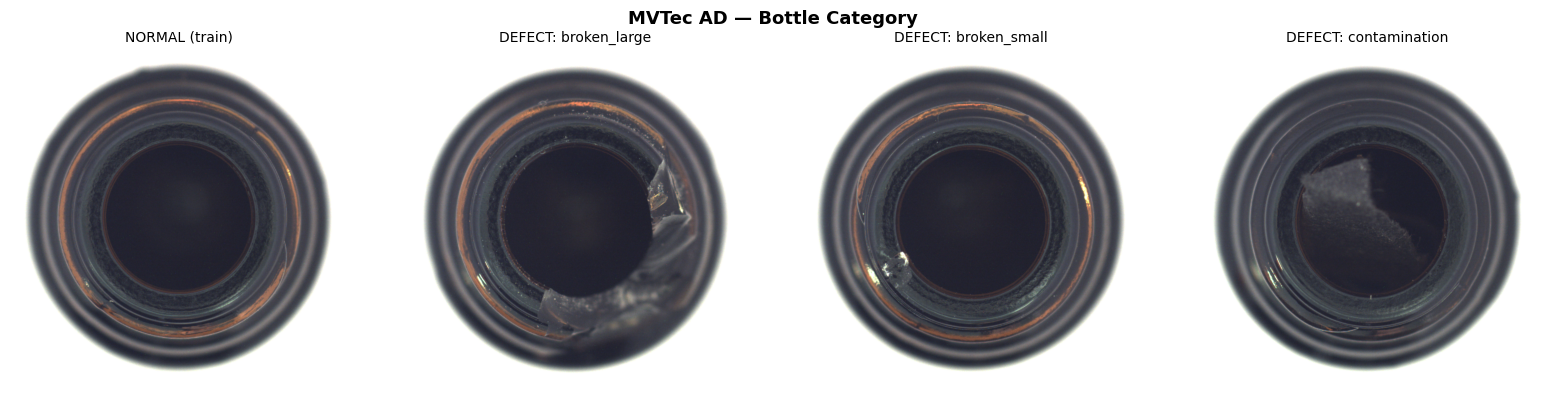

In [16]:
def read_rgb(path):
    return cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)

samples = [sorted(glob.glob(os.path.join(train_dir, "*.png")))[0]]
titles  = ["NORMAL (train)"]
for d in defect_types:
    p = sorted(glob.glob(os.path.join(test_dir, d, "*.png")))[0]
    samples.append(p)
    titles.append(f"DEFECT: {d}")

fig, axes = plt.subplots(1, len(samples), figsize=(4 * len(samples), 4))
for ax, path, title in zip(axes, samples, titles):
    ax.imshow(read_rgb(path))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.suptitle("MVTec AD — Bottle Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
# 2 - preprocessing

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform pipeline:")
for t in train_transform.transforms:
    print(f"  {t}")

Train transform pipeline:
  ToPILImage()
  Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  RandomHorizontalFlip(p=0.5)
  ToTensor()
  Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


In [19]:
# ── Custom Dataset class ──────────────────────────────────────────────────────
# In PyTorch, to manage your own data you create a class that INHERITS from Dataset.
# "Inheriting" means our class gets all the functionality of Dataset
# and overrides / adds methods specific to our data.
class MVTecDataset(Dataset):
    """PyTorch Dataset for one MVTec AD category."""

    # __init__ is the "constructor": called when we create an instance of the class
    # (e.g. MVTecDataset(DATASET_ROOT, split="train", transform=train_transform))
    def __init__(self, root, split="train", transform=None):
        self.transform   = transform  # preprocessing pipeline to apply to each image
        self.image_paths = []  # list of paths to all images
        self.labels      = []  # 0 = normal, 1 = defective
        self.mask_paths  = []  # paths to ground-truth masks (None for normal images)

        if split == "train":
            # glob.glob() finds all .png files in the train/good folder
            for p in sorted(glob.glob(os.path.join(root, "train", "good", "*.png"))):
                self.image_paths.append(p)
                self.labels.append(0)        # all training images are normal
                self.mask_paths.append(None) # no mask for normal images
        else:
            # For the test set, iterate over all defect types (including "good")
            for defect_type in sorted(os.listdir(os.path.join(root, "test"))):
                img_dir  = os.path.join(root, "test", defect_type)
                mask_dir = os.path.join(root, "ground_truth", defect_type)
                # If the type is "good" -> label 0 (normal), otherwise 1 (defective)
                label    = 0 if defect_type == "good" else 1
                for p in sorted(glob.glob(os.path.join(img_dir, "*.png"))):
                    self.image_paths.append(p)
                    self.labels.append(label)
                    if label == 1:
                        # Build the path to the corresponding mask:
                        # os.path.basename() extracts just the file name from the full path
                        # .replace() substitutes one substring with another
                        mask_name = os.path.basename(p).replace(".png", "_mask.png")
                        self.mask_paths.append(os.path.join(mask_dir, mask_name))
                    else:
                        self.mask_paths.append(None)

    # __len__ tells PyTorch how many images are in the dataset.
    # DataLoader calls this internally to know when to stop iterating.
    def __len__(self):
        return len(self.image_paths)

    # __getitem__ retrieves a single sample by index (like list[i]).
    # PyTorch calls this method for every image it needs to load.
    def __getitem__(self, idx):
        # Read the image and convert from BGR to RGB
        img = cv2.cvtColor(cv2.imread(self.image_paths[idx]), cv2.COLOR_BGR2RGB)
        # Apply the transformation pipeline if provided, otherwise just convert to tensor
        img = self.transform(img) if self.transform else T.ToTensor()(img)

        # ── Load the ground-truth mask ─────────────────────────────────────────
        mask_path = self.mask_paths[idx]
        if mask_path and os.path.exists(mask_path):
            # IMREAD_GRAYSCALE reads the image as a single-channel grey-scale array
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            if mask is not None:
                # Resize the mask to match the image dimensions
                mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE))
                # Convert to a binary mask: pixel > 0 -> 1 (defect), pixel = 0 -> 0 (normal)
                mask = (mask > 0).astype(np.uint8)
            else:
                # cv2.imread returned None: file exists but could not be decoded
                mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)
        else:
            # For normal images: all-zero mask (no defect)
            mask = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.uint8)

        # Return a tuple (image, label, mask)
        return img, self.labels[idx], mask

In [20]:
# ── Instantiate the datasets ──────────────────────────────────────────────────
# We create two MVTecDataset objects: one for training, one for testing
train_dataset = MVTecDataset(DATASET_ROOT, split="train", transform=train_transform)
test_dataset  = MVTecDataset(DATASET_ROOT, split="test",  transform=test_transform)

# ── Create the DataLoaders ────────────────────────────────────────────────────
# DataLoader wraps a Dataset and handles:
#   - loading data in batches of size batch_size
#   - optional random shuffling (shuffle=True)
#   - parallel loading with multiple worker processes (num_workers)
# batch_size=32: process 32 images at a time (balance between speed and GPU memory)
# shuffle=False: keep the original order (useful to align predictions with labels later)
# num_workers=0: data loading runs in the main process (avoids multiprocessing
#                issues in Colab that can cause shape mismatches between batches)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=0)

print(f"Train : {len(train_dataset)} images")
# sum() on a list of 0s and 1s counts how many equal 1 (the defective images)
print(f"Test  : {len(test_dataset)} images  ({sum(test_dataset.labels)} defective)")

# ── Verify tensor shapes ──────────────────────────────────────────────────────
# iter() creates an iterator from the DataLoader; next() pulls the first element (first batch)
imgs, labels, masks = next(iter(train_loader))
print(f"\nBatch shapes:")
# .shape returns the tensor dimensions as a torch.Size object
# list() converts it to a plain list for easier reading
# Image shape: (batch_size=32, channels=3, height=224, width=224)
print(f"  Images : {list(imgs.shape)}   → (batch, channels, H, W)")
print(f"  Labels : {list(labels.shape)}")
print(f"  Masks  : {list(masks.shape)}")

Train : 209 images
Test  : 83 images  (63 defective)

Batch shapes:
  Images : [32, 3, 224, 224]   → (batch, channels, H, W)
  Labels : [32]
  Masks  : [32, 224, 224]


In [21]:
# section 3

In [22]:
# ── Feature extractor definition ──────────────────────────────────────────────
# We create a class that inherits from nn.Module (the base class for all PyTorch networks)
class FeatureExtractor(nn.Module):
    """ResNet18 truncated after layer2. Outputs (B, 128, 28, 28) for 224x224 input."""

    def __init__(self):
        # super().__init__() calls the parent class constructor (nn.Module).
        # This is mandatory before defining any layers.
        super().__init__()

        # Load ResNet18 with weights pre-trained on ImageNet.
        # weights=ResNet18_Weights.IMAGENET1K_V1 downloads the weights automatically if not cached.
        backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

        # nn.Sequential() chains modules in series: the output of one becomes the input of the next.
        # We take only the first layers of ResNet18 up to layer2,
        # discarding layer3, layer4, and the final classifier (fc).
        # This way we "cut" the network and keep only the part that extracts local features.
        self.features = nn.Sequential(
            backbone.conv1,    # first convolutional layer: detects edges
            backbone.bn1,      # batch normalisation: stabilises values between layers
            backbone.relu,     # ReLU activation function: introduces non-linearity
            backbone.maxpool,  # reduces spatial resolution by 2x (max pooling)
            backbone.layer1,   # residual block 1: low-level features (simple textures)
            backbone.layer2,   # residual block 2: mid-level features (complex edges, patterns)
            # layer3, layer4 (too abstract) and fc (final classifier) are NOT used
        )

    # forward() defines what happens when we pass an input to the network (the "forward pass").
    # It is called automatically when we write model(input).
    def forward(self, x):
        return self.features(x)


# ── Instantiate and verify ────────────────────────────────────────────────────
# .to(DEVICE) moves the network to the GPU (if available) or CPU
# .eval() switches the network to evaluation mode: disables dropout and stochastic batch norm
model = FeatureExtractor().to(DEVICE).eval()

# Verify input/output shapes with a dummy all-zero tensor
# torch.no_grad() disables gradient computation (not needed during inference, saves memory)
with torch.no_grad():
    # Create a zero tensor of shape (1, 3, 224, 224) = 1 image, 3 channels, 224x224 pixels
    dummy = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)
    out   = model(dummy)

print(f"Input  : {list(dummy.shape)}")
# Expected output: (1, 128, 28, 28) = 1 image, 128 channels, 28x28 spatial map
print(f"Output : {list(out.shape)}")
# 28*28 = 784: each image produces 784 patch descriptors, each of dimension 128
print(f"\nEach image → {28 * 28} spatial patches × 128 features")

Input  : [1, 3, 224, 224]
Output : [1, 128, 28, 28]

Each image → 784 spatial patches × 128 features


In [23]:
# ── Decorator to disable gradient computation ─────────────────────────────────
# @torch.no_grad() is a "decorator": it modifies the behaviour of the function below it.
# Here it tells PyTorch not to compute gradients during execution.
# Gradients are only needed for training (backpropagation); since we are not training,
# disabling them saves memory and speeds up the computation.
@torch.no_grad()
def extract_features(loader, model, device):
    """Returns feature maps (N, 128, 28, 28) for all images in a DataLoader."""
    all_feats = []  # empty list where we accumulate features from each batch

    # The for loop iterates over all batches in the DataLoader
    # tqdm() wraps the iterable and displays a progress bar
    # desc= sets the descriptive text next to the bar
    for imgs, _, _ in tqdm(loader, desc="Extracting"):
        # _ (underscore) is a "throwaway" variable (labels and masks are not needed here)
        # imgs.to(device) moves the batch to the GPU/CPU
        feats = model(imgs.to(device))   # forward pass: (B, 3, 224, 224) -> (B, 128, 28, 28)
        all_feats.append(feats.cpu())    # .cpu() moves the tensor back to RAM (from GPU VRAM)

    # torch.cat() concatenates all tensors in the list along dimension 0 (images)
    # Result: (N_total, 128, 28, 28) where N_total = total number of images
    return torch.cat(all_feats, dim=0)


print("Extracting training features...")
train_features = extract_features(train_loader, model, DEVICE)

print("Extracting test features...")
test_features  = extract_features(test_loader,  model, DEVICE)

print(f"\nTrain features : {train_features.shape}")
print(f"Test  features : {test_features.shape}")

Extracting training features...


Extracting: 100%|██████████| 7/7 [00:26<00:00,  3.73s/it]


Extracting test features...


Extracting: 100%|██████████| 3/3 [02:25<00:00, 48.62s/it]


Train features : torch.Size([209, 128, 28, 28])
Test  features : torch.Size([83, 128, 28, 28])


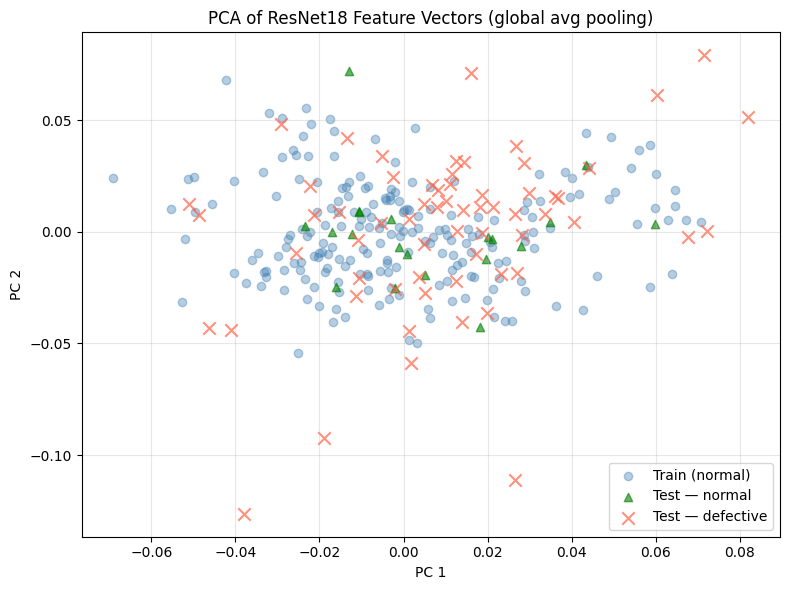

Variance explained by PC1+PC2: 23.9%


In [24]:
# ── Dimensionality reduction for feature visualisation ────────────────────────
# Feature maps have shape (N, 128, 28, 28). To visualise them in 2D we use PCA.
# First we "collapse" the spatial dimensions (28x28) with Global Average Pooling:
# we average over all spatial positions -> each image becomes a 128-dimensional vector.
# .mean(dim=[2, 3]) computes the mean over dimensions 2 and 3 (height and width)
# .numpy() converts the PyTorch tensor to a NumPy array (required by scikit-learn)
train_pooled = train_features.mean(dim=[2, 3]).numpy()  # (N_train, 128)
test_pooled  = test_features.mean(dim=[2, 3]).numpy()   # (N_test, 128)
test_labels  = np.array(test_dataset.labels)            # labels: 0=normal, 1=defective

# ── PCA: from 128 dimensions down to 2 ───────────────────────────────────────
# PCA(n_components=2) finds the 2 directions of maximum variance in the 128-dim space.
# .fit() computes the principal components on the training data.
# .transform() projects the data onto the 2 new dimensions.
pca = PCA(n_components=2).fit(train_pooled)
train_2d = pca.transform(train_pooled)  # (N_train, 2): 2D coordinates for each training image
test_2d  = pca.transform(test_pooled)   # (N_test, 2): 2D coordinates for each test image

# ── Scatter plot visualisation ────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
# Blue dots: training images (all normal)
plt.scatter(train_2d[:, 0], train_2d[:, 1],
            c="steelblue", alpha=0.4, label="Train (normal)")
# Green triangles: normal test images (test_labels == 0)
# Boolean indexing: test_2d[mask, :] selects only rows where mask is True
plt.scatter(test_2d[test_labels == 0, 0], test_2d[test_labels == 0, 1],
            c="green", alpha=0.6, marker="^", label="Test — normal")
# Red crosses: defective test images (test_labels == 1)
plt.scatter(test_2d[test_labels == 1, 0], test_2d[test_labels == 1, 1],
            c="tomato", alpha=0.7, marker="x", s=80, label="Test — defective")
plt.xlabel("PC 1")   # first principal component
plt.ylabel("PC 2")   # second principal component
plt.title("PCA of ResNet18 Feature Vectors (global avg pooling)")
plt.legend()
plt.grid(True, alpha=0.3)  # semi-transparent background grid
plt.tight_layout()
plt.show()
# explained_variance_ratio_ shows how much total variance the chosen components capture
print(f"Variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum():.1%}")

In [ ]:
# 4

In [25]:
# ── Build the Memory Bank ─────────────────────────────────────────────────────
# The memory bank is the "database" of all normal patches seen during training.
# Each training image produces 28x28 = 784 patch descriptors of dimension 128.
# We collect all these descriptors into a 2D matrix (rows = patches, columns = features).

# train_features has shape (N_train, 128, 28, 28)
N, C, H, W  = train_features.shape  # unpack the 4 dimensions into separate variables

# .permute(0, 2, 3, 1) reorders dimensions: (N, 128, 28, 28) -> (N, 28, 28, 128)
# .reshape(-1, C) flattens the first 3 dimensions into one:
#   (N, 28, 28, 128) -> (N*28*28, 128) = (N*784, 128)
#   -1 means "infer this dimension automatically"
# .numpy() converts to a NumPy array for scikit-learn
memory_bank = train_features.permute(0, 2, 3, 1).reshape(-1, C).numpy()
print(f"Full memory bank : {memory_bank.shape}")

# ── Sub-sample to keep memory manageable on free Colab ───────────────────────
# With 209 training images: 209 * 784 = ~164,000 patches -> could exhaust Colab RAM
# We draw a random subset of MAX_PATCHES patches
MAX_PATCHES = 50_000  # the underscore is just a readability separator (= 50000)
if len(memory_bank) > MAX_PATCHES:
    # np.random.choice() picks MAX_PATCHES random indices without replacement
    idx = np.random.choice(len(memory_bank), MAX_PATCHES, replace=False)
    memory_bank = memory_bank[idx]   # select only the rows at the chosen indices
    print(f"Subsampled to    : {memory_bank.shape}")

# ── Fit the k-NN ──────────────────────────────────────────────────────────────
# NearestNeighbors is scikit-learn's k-NN algorithm: the same API you already know!
# n_neighbors=9: for each test patch, find its 9 nearest neighbours
# metric="euclidean": use Euclidean distance (square root of sum of squared differences)
# algorithm="ball_tree": efficient data structure for nearest-neighbour search in high dimensions
# n_jobs=-1: use all available CPU cores to parallelise the search
knn = NearestNeighbors(n_neighbors=9, metric="euclidean",
                       algorithm="ball_tree", n_jobs=-1)
knn.fit(memory_bank)  # .fit() stores all normal patches (no "training" in the classical sense)
print("k-NN fitted on memory bank.")

Full memory bank : (163856, 128)
Subsampled to    : (50000, 128)
k-NN fitted on memory bank.


In [26]:
def compute_scores(features, knn):
    """
    Returns:
      image_scores (N,)      — max patch score per image
      patch_maps   (N, H, W) — spatial anomaly map per image
    """
    # Unpack the feature tensor dimensions
    N, C, H, W = features.shape  # N=num images, C=128 channels, H=W=28 (spatial map)

    # Reshape: (N, C, H, W) -> (N, H*W, C) = (N, 784, 128)
    # Each image becomes a matrix of 784 rows (patches) x 128 columns (features)
    patches = features.permute(0, 2, 3, 1).reshape(N, H * W, C).numpy()

    image_scores = []  # one anomaly score per image
    patch_maps   = []  # one 28x28 spatial map per image

    # Iterate over each image individually (range(N) generates [0, 1, 2, ..., N-1])
    for i in tqdm(range(N), desc="Scoring"):
        # knn.kneighbors(patches[i]) finds the 9 nearest neighbours for each of the 784 patches
        # patches[i] has shape (784, 128): 784 query vectors, each of dimension 128
        # dists has shape (784, 9): for each patch, the distances to its 9 nearest neighbours
        # _ (neighbour indices) is not needed, we only use the distances
        dists, _    = knn.kneighbors(patches[i])  # (784, 9)

        # Per-patch score = mean distance to the k neighbours
        # .mean(axis=1) averages across columns (the 9 neighbours) -> (784,)
        patch_score = dists.mean(axis=1)

        # Reshape the 784 scores into a 28x28 spatial map
        spatial_map = patch_score.reshape(H, W)

        # Image score = maximum value across all patches
        # (a single anomalous patch is enough to flag the whole image as defective)
        image_scores.append(spatial_map.max())
        patch_maps.append(spatial_map)

    # np.array() converts the list of scalars to a NumPy array of shape (N,)
    # np.stack() stacks the N maps of shape (28, 28) into an array of shape (N, 28, 28)
    return np.array(image_scores), np.stack(patch_maps)


image_scores, patch_maps = compute_scores(test_features, knn)
print(f"Image scores : {image_scores.shape}")
print(f"Patch maps   : {patch_maps.shape}")

Scoring: 100%|██████████| 83/83 [07:54<00:00,  5.72s/it]

Image scores : (83,)
Patch maps   : (83, 28, 28)


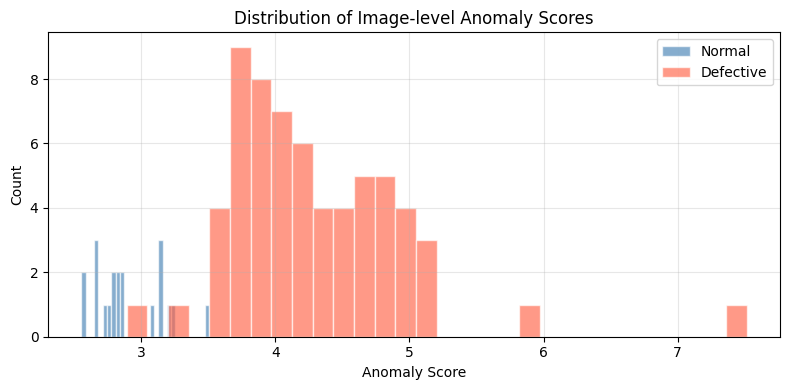

Normal    — mean: 2.902  std: 0.250
Defective — mean: 4.297  std: 0.674


In [27]:
# ── Split scores by category ──────────────────────────────────────────────────
# NumPy "boolean indexing": array[mask] selects only elements where the mask is True
normal_scores  = image_scores[test_labels == 0]   # scores for normal images
anomaly_scores = image_scores[test_labels == 1]   # scores for defective images

# ── Histogram of score distributions ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

# ax.hist() draws a histogram: groups values into "bins" and counts how many fall in each
# bins=30: divide the value range into 30 intervals
# alpha=0.65: opacity (0=transparent, 1=opaque); useful to see the overlap between distributions
# edgecolor: colour of each bar's border
ax.hist(normal_scores,  bins=30, alpha=0.65, label="Normal",
        color="steelblue", edgecolor="white")
ax.hist(anomaly_scores, bins=30, alpha=0.65, label="Defective",
        color="tomato",   edgecolor="white")

ax.set_xlabel("Anomaly Score")
ax.set_ylabel("Count")
ax.set_title("Distribution of Image-level Anomaly Scores")
ax.legend()  # display the legend (links colours to labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# .mean() and .std() compute the mean and standard deviation of the array
# :.3f formats the number with 3 decimal places
print(f"Normal    — mean: {normal_scores.mean():.3f}  std: {normal_scores.std():.3f}")
print(f"Defective — mean: {anomaly_scores.mean():.3f}  std: {anomaly_scores.std():.3f}")

In [ ]:
# section 5

In [28]:
def build_anomaly_maps(patch_maps, target_size=IMAGE_SIZE, sigma=4):
    """Gaussian smooth + bilinear upsample (N, 28, 28) -> (N, target_size, target_size)."""
    maps = []

    # Iterate over each 28x28 map (one per test image)
    for pm in patch_maps:

        # STEP 1 — Gaussian smoothing
        # gaussian_filter() blurs the map by applying a Gaussian filter.
        # sigma controls the "width" of the blur: larger values -> more blurring.
        # This removes blocky artefacts at the boundaries between adjacent patches.
        smoothed  = gaussian_filter(pm, sigma=sigma)

        # STEP 2 — Bilinear upsampling
        # cv2.resize() rescales the image; INTER_LINEAR uses bilinear interpolation:
        # new pixel values are computed as a weighted average of neighbouring pixels.
        # We scale the map from 28x28 up to 224x224 (the original image resolution).
        upsampled = cv2.resize(smoothed, (target_size, target_size),
                               interpolation=cv2.INTER_LINEAR)
        maps.append(upsampled)

    # np.stack() stacks the maps into a single array of shape (N, 224, 224)
    return np.stack(maps)


anomaly_maps = build_anomaly_maps(patch_maps)
print(f"Anomaly maps: {anomaly_maps.shape}")

Anomaly maps: (83, 224, 224)


In [29]:
def make_binary_mask(anomaly_map, percentile=95):
    """Normalize -> threshold -> morphological cleaning. Returns (norm_map, binary_mask)."""

    # STEP 1 — Min-max normalisation: scale values to the interval [0, 1]
    # Formula: (x - min) / (max - min)
    # 1e-8 is a small value added to the denominator to avoid division by zero
    # (if min == max, all pixels would have the same score)
    vmin, vmax = anomaly_map.min(), anomaly_map.max()
    norm_map   = (anomaly_map - vmin) / (vmax - vmin + 1e-8)

    # STEP 2 — Percentile-based thresholding
    # np.percentile(array, 95) finds the value below which 95% of pixels fall
    # -> the top 5% of pixels are considered "anomalous"
    thresh = np.percentile(norm_map, percentile)
    # Create a binary mask: 1 where the pixel is above the threshold, 0 elsewhere
    # .astype(np.uint8) converts booleans to integers (0/1) as required by OpenCV
    binary = (norm_map >= thresh).astype(np.uint8)

    # STEP 3 — Morphological operations to clean up the mask
    # cv2.getStructuringElement() creates a "kernel" (structuring element) shaped as an ellipse
    # of size 5x5. The kernel is the "tool" used by morphological operations.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

    # MORPH_CLOSE = dilation followed by erosion:
    # fills small holes inside white regions (detected defects)
    closed  = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

    # MORPH_OPEN = erosion followed by dilation:
    # removes small isolated white dots (noise) that are not part of real defects
    cleaned = cv2.morphologyEx(closed, cv2.MORPH_OPEN,  kernel)

    return norm_map, cleaned   # return both the continuous map and the binary mask


# ── Apply to all test images ──────────────────────────────────────────────────
# Collect ground-truth masks for every image in the test set
# test_dataset[i] returns the tuple (img, label, mask); [2] picks only the mask
test_masks_gt  = np.stack([test_dataset[i][2] for i in range(len(test_dataset))])
pred_norm_maps = []   # normalised anomaly maps (continuous values in [0, 1])
pred_masks     = []   # predicted binary masks (values 0 or 1)

for amap in anomaly_maps:
    nmap, mask = make_binary_mask(amap, percentile=95)
    pred_norm_maps.append(nmap)
    pred_masks.append(mask)

# Convert lists to NumPy arrays for subsequent vectorised operations
pred_norm_maps = np.stack(pred_norm_maps)
pred_masks     = np.stack(pred_masks)
print(f"Predicted masks: {pred_masks.shape}")

Predicted masks: (83, 224, 224)


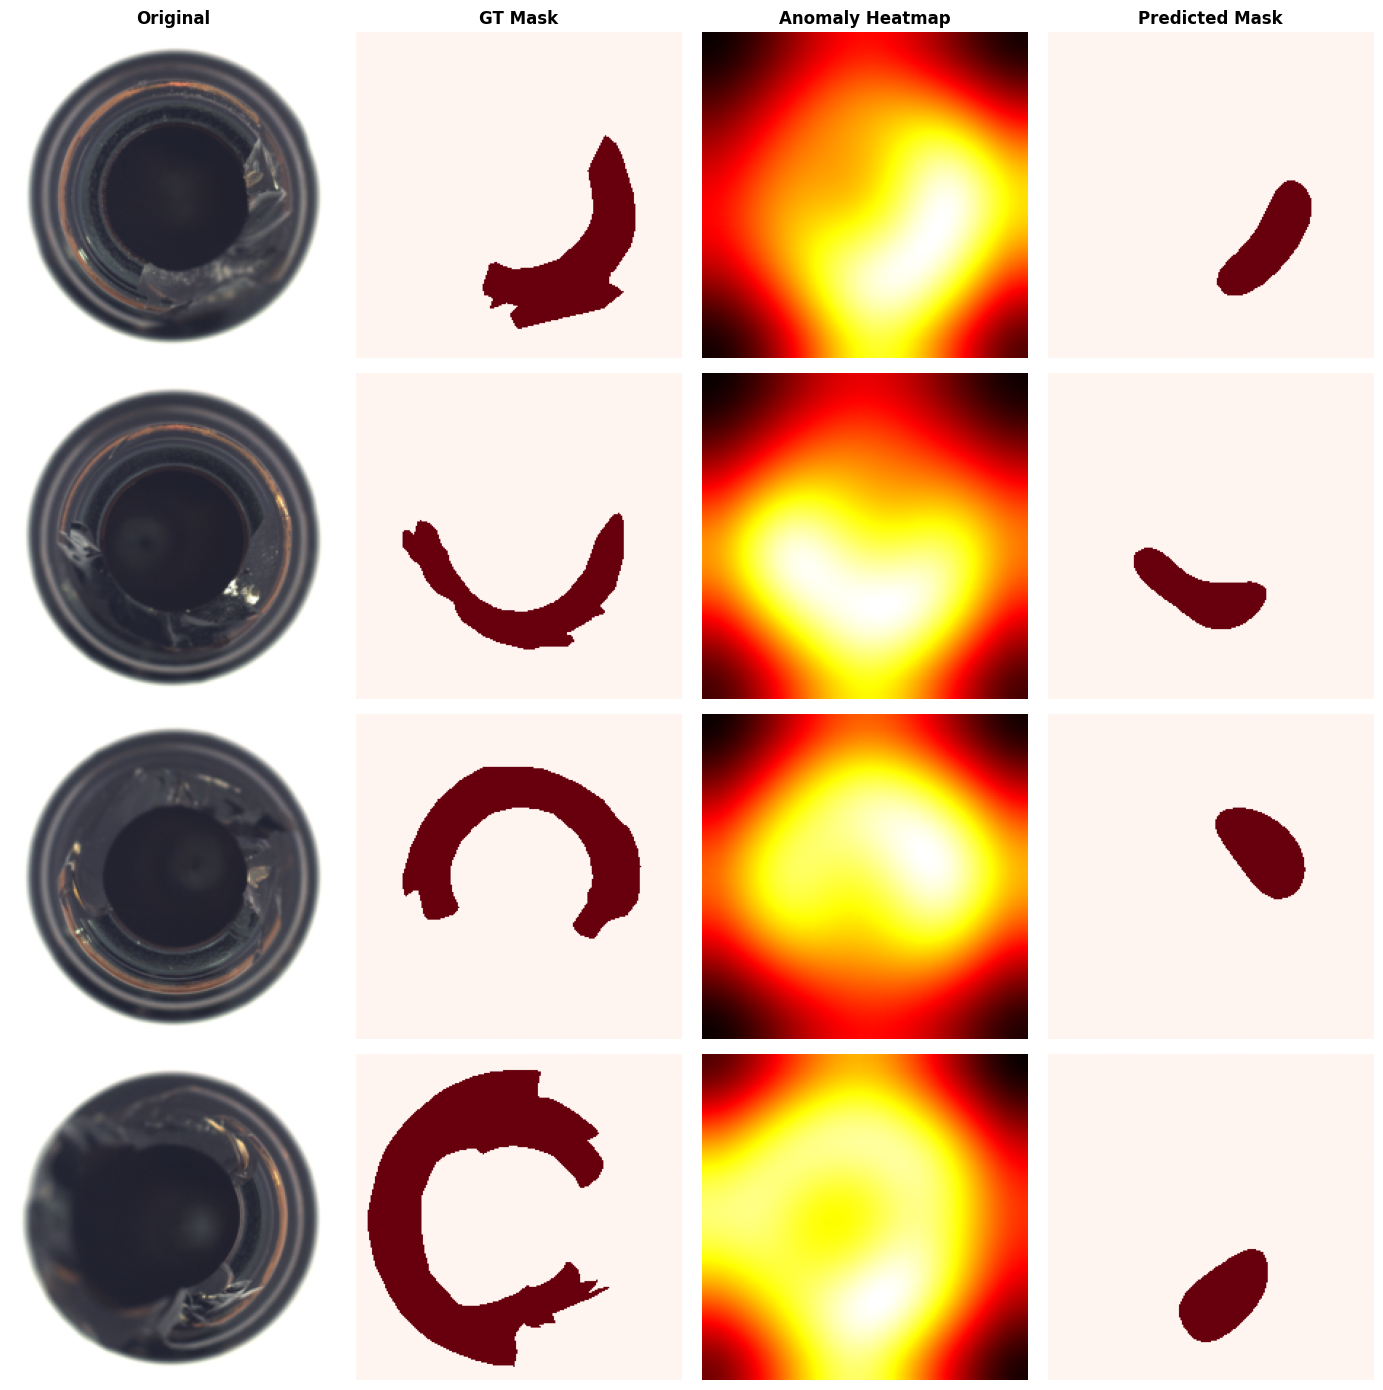

In [30]:
# ── De-normalisation helper to display original images ────────────────────────
# Images in the dataset are normalised (mean subtracted, divided by std).
# To display them correctly we must invert that operation.
def denormalize(tensor):
    # Create mean and std tensors with shape (3, 1, 1) to leverage broadcasting:
    # PyTorch allows operations between tensors of different shapes when dimensions are compatible.
    # (3, 1, 1) can operate with (3, H, W) by applying the values to every pixel.
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

    # Invert normalisation: x_orig = x_norm * std + mean
    # .clamp(0, 1) clips values outside [0, 1] (fixes minor numerical errors)
    # .permute(1, 2, 0) reorders from (C, H, W) to (H, W, C) as required by matplotlib
    # .numpy() converts to a NumPy array
    return (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


# Take the first 4 indices of defective images in the test set
# np.where() returns a tuple of arrays with indices where the condition is True
# [0] picks the first (and only) array from the tuple; [:4] takes the first 4 elements
defect_indices = np.where(test_labels == 1)[0][:4]

# ── 4x4 visualisation grid ────────────────────────────────────────────────────
# 4 rows (one per defective image) x 4 columns (original, GT mask, heatmap, predicted mask)
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

# Column headers (only in the first row)
for col, title in enumerate(["Original", "GT Mask", "Anomaly Heatmap", "Predicted Mask"]):
    axes[0, col].set_title(title, fontsize=12, fontweight="bold")

# enumerate() adds a counter (row=0,1,2,3) to the elements of the list
for row, idx in enumerate(defect_indices):
    img_t, label, gt_mask = test_dataset[idx]   # retrieve the sample

    axes[row, 0].imshow(denormalize(img_t))             # original image (de-normalised)
    axes[row, 1].imshow(gt_mask, cmap="Reds", vmin=0, vmax=1)         # ground-truth mask
    axes[row, 2].imshow(pred_norm_maps[idx], cmap="hot")               # anomaly heatmap
    axes[row, 3].imshow(pred_masks[idx], cmap="Reds", vmin=0, vmax=1) # predicted binary mask

    # Hide axes for all panels in the current row
    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# section 6

In [31]:
# ── Compute image-level AUROC ─────────────────────────────────────────────────
# roc_auc_score() is the same scikit-learn function you already know!
# First argument:  test_labels   -> true labels (0=normal, 1=defective)
# Second argument: image_scores  -> predicted scores (continuous values)
# Returns the area under the ROC curve (between 0.5 and 1.0)
auroc_image = roc_auc_score(test_labels, image_scores)
print(f"Image-level AUROC: {auroc_image:.4f}")

Image-level AUROC: 0.9937


In [32]:
def pixel_metrics(gt_masks, pred_masks, labels):
    """Pixel-level IoU and Dice, evaluated only on defective images."""

    # Compute metrics only on defective images (label == 1)
    # labels == 1 creates a boolean mask used to select the corresponding rows
    mask = labels == 1
    # .astype(bool) converts 0/1 to False/True so we can use logical operators & (AND) and | (OR)
    gt   = gt_masks[mask].astype(bool)    # ground-truth masks for defective images
    pred = pred_masks[mask].astype(bool)  # predicted masks for defective images

    # & = pixel-wise logical AND: True only where BOTH masks are 1 (intersection)
    # | = pixel-wise logical OR:  True where AT LEAST ONE mask is 1 (union)
    # .sum() counts True pixels (equivalent to counting "white" pixels in the mask)
    intersect  = (gt & pred).sum()
    union      = (gt | pred).sum()

    # IoU (Intersection over Union) = |intersection| / |union|
    # float() converts the NumPy result to a standard Python number
    iou  = float(intersect / (union + 1e-8))

    # Dice = 2 * |intersection| / (|predicted| + |ground truth|)
    dice = float(2 * intersect / (gt.sum() + pred.sum() + 1e-8))

    return iou, dice


iou, dice = pixel_metrics(test_masks_gt, pred_masks, test_labels)

# ── Print the final metrics summary ───────────────────────────────────────────
print("─────────────────────────────────────")
print(f"  Image-level AUROC : {auroc_image:.4f}")
print(f"  Pixel-level IoU   : {iou:.4f}")
print(f"  Pixel-level Dice  : {dice:.4f}")
print("─────────────────────────────────────")

─────────────────────────────────────
  Image-level AUROC : 0.9937
  Pixel-level IoU   : 0.2779
  Pixel-level Dice  : 0.4349
─────────────────────────────────────


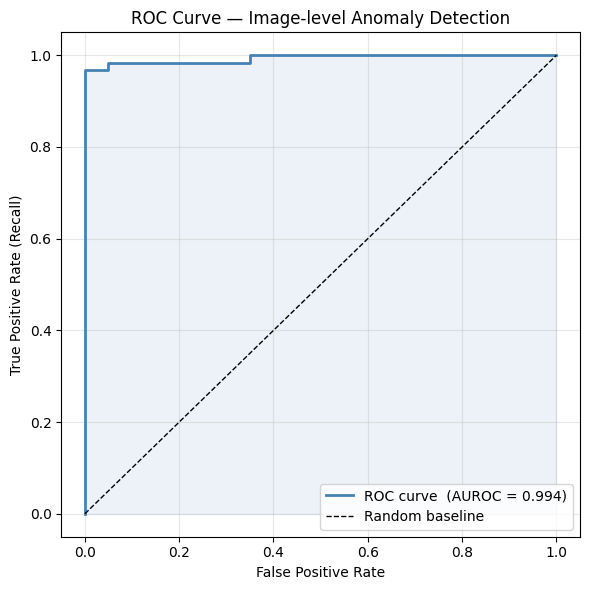

In [33]:
# ── Compute the ROC curve ─────────────────────────────────────────────────────
# roc_curve() returns three arrays:
# fpr: False Positive Rate (false alarms) at each possible threshold
# tpr: True Positive Rate = Recall (defects correctly detected) at each threshold
# _  : the thresholds used (not needed here)
# By sweeping the threshold from 0 to +inf we get all points on the curve
fpr, tpr, _ = roc_curve(test_labels, image_scores)

plt.figure(figsize=(6, 6))

# Plot the ROC curve: X axis = FPR (false alarms), Y axis = TPR (sensitivity)
# lw=2: line width
# label: legend text; we include the already-computed AUROC
plt.plot(fpr, tpr, color="steelblue", lw=2,
         label=f"ROC curve  (AUROC = {auroc_image:.3f})")

# Dashed diagonal: random baseline (AUROC = 0.5, random classifier)
plt.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")

# fill_between() shades the area under the ROC curve
# alpha=0.1: nearly transparent, just to highlight the area
plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Image-level Anomaly Detection")
plt.legend(loc="lower right")  # legend position
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

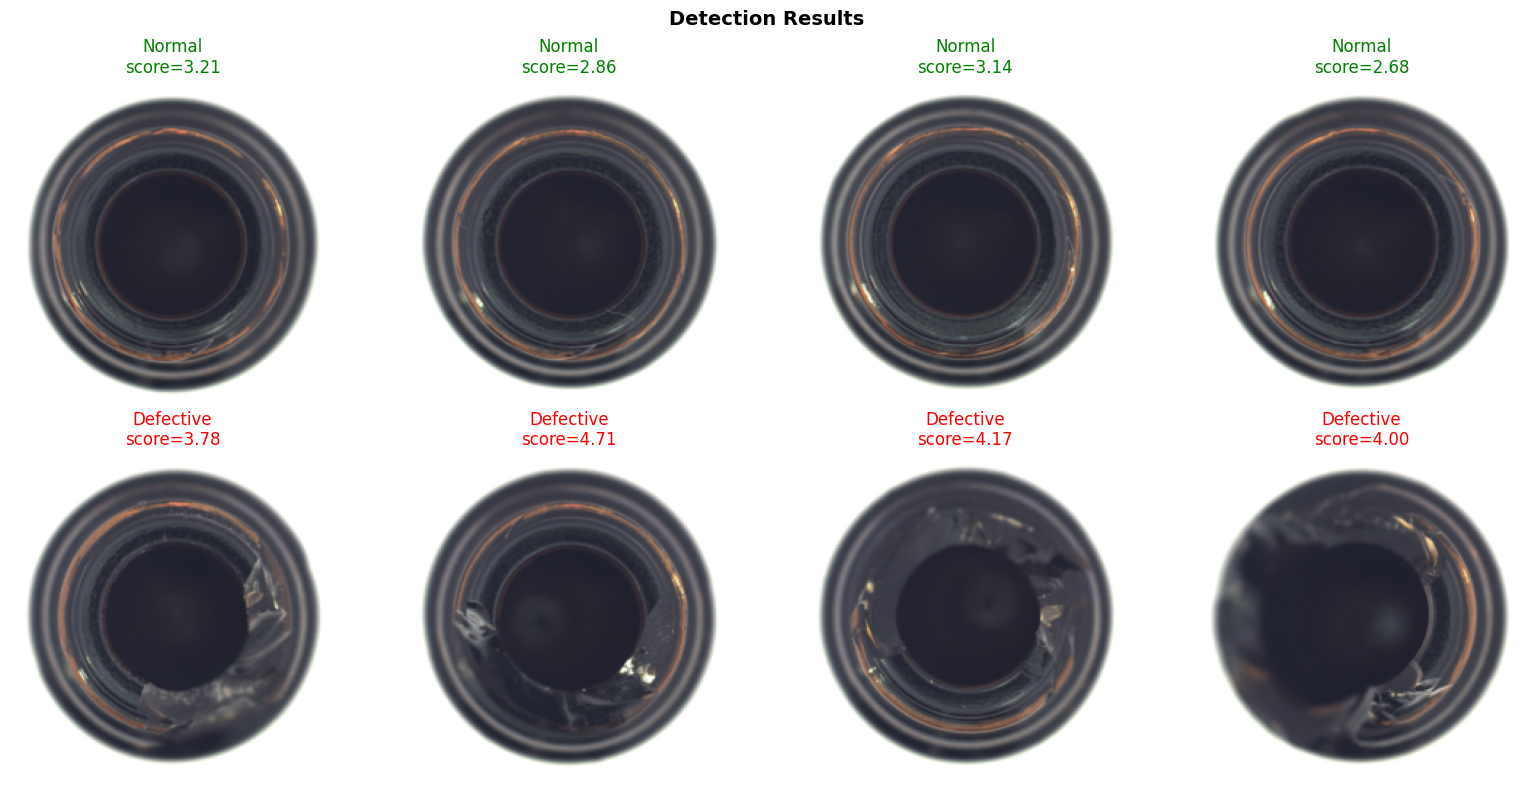

In [34]:
# ── Comparison grid: normal vs defective images ───────────────────────────────
# Create a 2x4 grid: row 0 = normal images, row 1 = defective images
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Detection Results", fontsize=14, fontweight="bold")

# Select 4 normal and 4 defective images from the test set
# np.where() returns the indices where the condition is True
# [0] picks the first array from the tuple returned by where; [:4] takes the first 4 elements
normal_idx = np.where(test_labels == 0)[0][:4]
defect_idx = np.where(test_labels == 1)[0][:4]

# zip() pairs normal and defective indices element-by-element
# enumerate() adds the column number: col=0,1,2,3
for col, (ni, di) in enumerate(zip(normal_idx, defect_idx)):

    # For each column display 2 images: row 0 = normal, row 1 = defective
    for row, idx in enumerate([ni, di]):
        img_t, label, _ = test_dataset[idx]  # _ discards the mask

        # Set caption text and colour based on the label
        caption = "Normal"    if label == 0 else "Defective"
        color   = "green"     if label == 0 else "red"

        axes[row, col].imshow(denormalize(img_t))
        # Title: category + anomaly score (:.2f = 2 decimal places)
        axes[row, col].set_title(f"{caption}\nscore={image_scores[idx]:.2f}", color=color)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()